In [1]:
%matplotlib inline
from nwm_routing.nhf_routing import nhf_routing
import os
from pathlib import Path
import logging
import xarray as xr
import matplotlib.pyplot as plt

logging.getLogger("matplotlib").setLevel(logging.WARNING)

if Path().cwd().name != "data":  # Guard against reruns
    os.chdir("data/")

In [2]:
REF_DATA = Path("config/gage_reference_data.nc")
OUT_DIR  = Path("comparison_plots")
OUT_DIR.mkdir(exist_ok=True)

C_USGS = "#1a1a1a"
C_A    = "#2166ac"
C_B    = "#d6604d"

SITES = ["07381482", "07381490", "07374000", "07289000"]


def load_output(output_dir: Path) -> xr.Dataset:
    files = sorted(Path(output_dir).glob("*.nc"))
    if not files:
        raise FileNotFoundError(
            f"No .nc files found in '{output_dir}'. "
            "Run the routing configuration before plotting."
        )
    return xr.concat([xr.open_dataset(p, engine="netcdf4") for p in files], dim="time")


# The runs start 2011-04-19 from restarts written by a five-day spin-up of each case
# (see setup in test_old_river.py); the reference data reaches back to 04-14, so the
# plots begin where the runs do.
def get_troute_flow(out_ds, fp_id, first_t, last_t):
    trdf = out_ds.sel(feature_id=fp_id).to_dataframe().reset_index()
    return trdf[(trdf["time"] >= first_t) & (trdf["time"] <= last_t)]


def compare_runs(
    output_a: str | Path,
    output_b: str | Path,
    sites: list[str],
    label_a: str = "Run A",
    label_b: str = "Run B",
    suffix: str = "",
    ref_data: Path = REF_DATA,
    out_dir: Path = OUT_DIR,
):
    """Plot observed vs two T-Route runs for each requested gage.

    Parameters
    ----------
    output_a, output_b : directories containing chunked .nc output files
    sites              : list of USGS site numbers to plot
    label_a, label_b   : legend labels for each run
    suffix             : string appended to the output filename (e.g. "_diversion")
    """
    ds    = xr.open_dataset(ref_data)
    ds_a  = load_output(output_a)
    ds_b  = load_output(output_b)

    site_indices = [
        int(i)
        for i, sn in enumerate(ds["site_no"].values)
        if sn in sites
    ]
    assert len(site_indices) == len(sites), (
        f"Not all requested sites found. Available: {list(ds['site_no'].values)}"
    )

    for gage_idx in site_indices:
        sub     = ds.sel(gage=gage_idx)
        site_no = sub["site_no"].item()
        fp_id   = sub["fp_id"].item()
        first_t = max(ds_a["time"].values[0], ds_b["time"].values[0])
        last_t  = sub["time"].values[-1]
        shown   = sub["time"].values >= first_t

        trdf_a = get_troute_flow(ds_a, fp_id, first_t, last_t)
        trdf_b = get_troute_flow(ds_b, fp_id, first_t, last_t)

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(
            trdf_a["time"], trdf_a["flow"],
            label=label_a, color=C_A, linewidth=1.5,
            marker="o", markevery=30, markersize=4, markerfacecolor="w", zorder=2,
        )
        ax.plot(
            trdf_b["time"], trdf_b["flow"],
            label=label_b, color=C_B, linewidth=1.5,
            marker="s", markevery=30, markersize=4, markerfacecolor="w", zorder=3,
        )
        ax.plot(
            sub["time"].values[shown], sub["usgs_q"].values[shown] / 35.31,
            label=f"USGS {site_no}", color=C_USGS, linewidth=2, zorder=4,
        )
        ax.set_xlabel("Date")
        ax.set_ylabel("Discharge (cms)")
        ax.legend(framealpha=0.9, fontsize=10)
        ax.set_title(f"USGS Site {site_no}  —  fp_id: {fp_id}", fontsize=12)
        ax.set_facecolor("whitesmoke")
        ax.grid(color="white", linewidth=0.8)
        fig.autofmt_xdate()
        fig.tight_layout()
        fig.savefig(out_dir / f"{site_no}{suffix}.png", dpi=150)
        plt.show()


def compare_retro(
    sites: list[str],
    ref_data: Path = REF_DATA,
    out_dir: Path = OUT_DIR,
):
    """Plot NWM retrospective vs. USGS observed for each requested gage.

    Uses solid/dashed black lines with no color to show the pre-DA baseline.

    Parameters
    ----------
    sites    : list of USGS site numbers to plot
    ref_data : path to gage_reference_data.nc
    out_dir  : directory to save figures
    """
    ds = xr.open_dataset(ref_data)

    site_indices = [
        int(i)
        for i, sn in enumerate(ds["site_no"].values)
        if sn in sites
    ]
    assert len(site_indices) == len(sites), (
        f"Not all requested sites found. Available: {list(ds['site_no'].values)}"
    )

    for gage_idx in site_indices:
        sub     = ds.sel(gage=gage_idx)
        site_no = sub["site_no"].item()
        fp_id   = sub["fp_id"].item()

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(
            sub["time"].values, sub["retrospective_q"].values,
            label="NWM v3.0 Retrospective", color=C_USGS, linewidth=1.5,
            linestyle="--", zorder=2,
        )
        ax.plot(
            sub["time"].values, sub["usgs_q"].values / 35.31,
            label=f"USGS {site_no}", color=C_USGS, linewidth=2,
            linestyle="-", zorder=3,
        )
        ax.set_xlabel("Date")
        ax.set_ylabel("Discharge (cms)")
        ax.legend(framealpha=0.9, fontsize=10)
        ax.set_title(f"USGS Site {site_no}  —  fp_id: {fp_id}", fontsize=12)
        ax.set_facecolor("whitesmoke")
        ax.grid(color="white", linewidth=0.8)
        fig.autofmt_xdate()
        fig.tight_layout()
        fig.savefig(out_dir / f"{site_no}_retro.png", dpi=150)
        plt.show()


In [3]:
nhf_routing(["-f", "config.yaml"])
nhf_routing(["-f", "config_no_diversion.yaml"])

2026-09-15 16:35:26,509 - TROUTE - INFO - [NHF.py:87 - __init__]: creating NHF supernetwork connections set


2026-09-15 16:35:26,579 - TROUTE - INFO - [nhf_preprocess.py:732 - _clean_waterbodies]: waterbodies: 3 of 3 lakes retained for reservoir routing


2026-09-15 16:35:26,604 - TROUTE - WARNING - [nhf_preprocess.py:1496 - _one_link_per_gage]: gages: 1 USGS gage(s) share a routing link with another gage; keeping the active gage nearest the downstream nexus and dropping the rest, e.g. ['07293500']


2026-09-15 16:35:26,604 - TROUTE - INFO - [nhf_preprocess.py:1506 - _one_link_per_gage]: gages: 8 USGS gage(s) placed on 8 routing link(s)


2026-09-15 16:35:26,618 - TROUTE - DEBUG - [nhf_preprocess.py:1648 - _resolve_diversion_da]: Diversion configured: fp_id 1270479816524705 (node 1271023511891281) -> gage 07381482 (node 1271023511890341)


...

2026-09-15 16:37:08,024 - TROUTE - INFO - [nhf_routing.py:459 - nhf_routing]: Forcing array construction: 34.3 secs, 68.65 %


2026-09-15 16:37:08,024 - TROUTE - INFO - [nhf_routing.py:466 - nhf_routing]: Routing computations: 14.9 secs, 29.82 %


2026-09-15 16:37:08,024 - TROUTE - INFO - [nhf_routing.py:473 - nhf_routing]: Output writing: 0.66 secs, 1.33 %


2026-09-15 16:37:08,024 - TROUTE - INFO - [nhf_routing.py:480 - nhf_routing]: ----------------------------------------


2026-09-15 16:37:08,024 - TROUTE - INFO - [nhf_routing.py:481 - nhf_routing]: Total execution time: 49.959999999999994 secs


/var/folders/jx/s06wj7hs325c_2yd2g5209sr0000gp/T/ipykernel_95104/573723478.py:19: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.concat([xr.open_dataset(p, engine="netcdf4") for p in files], dim="time")
/var/folders/jx/s06wj7hs325c_2yd2g5209sr0000gp/T/ipykernel_95104/573723478.py:19: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or 

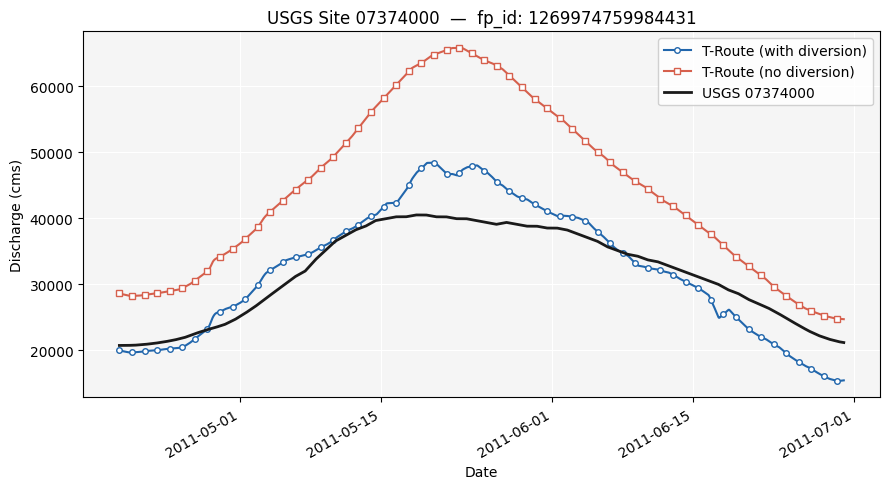

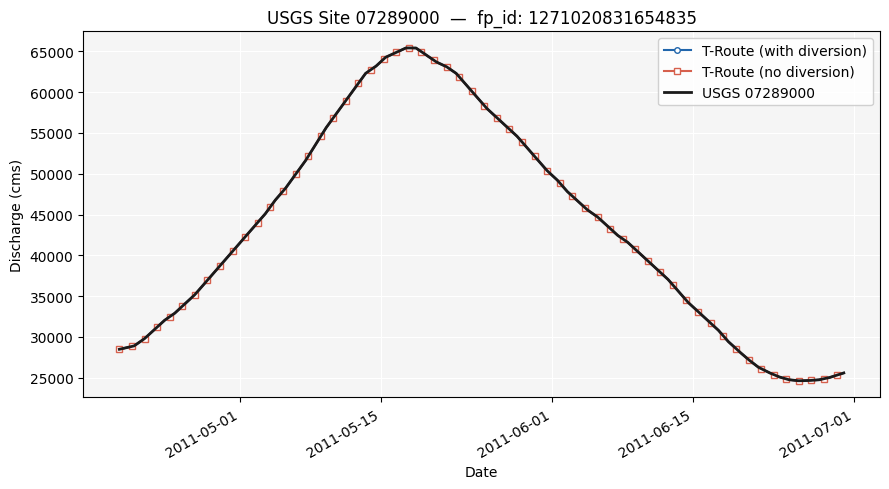

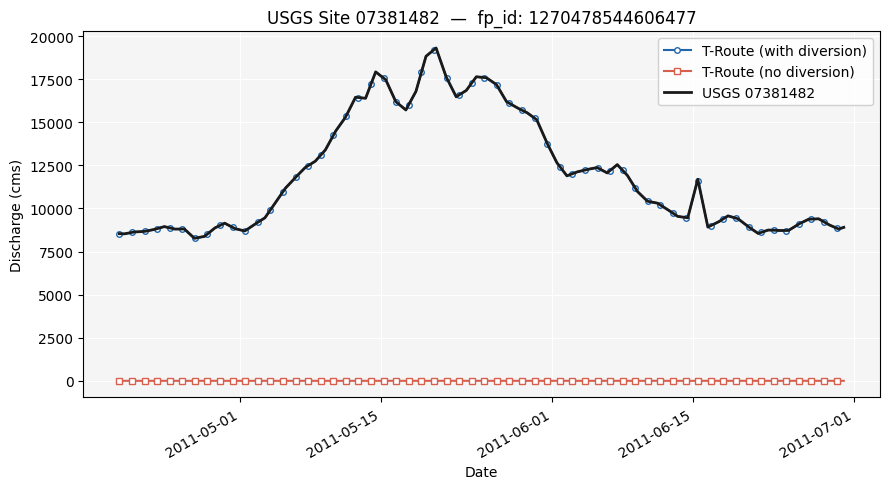

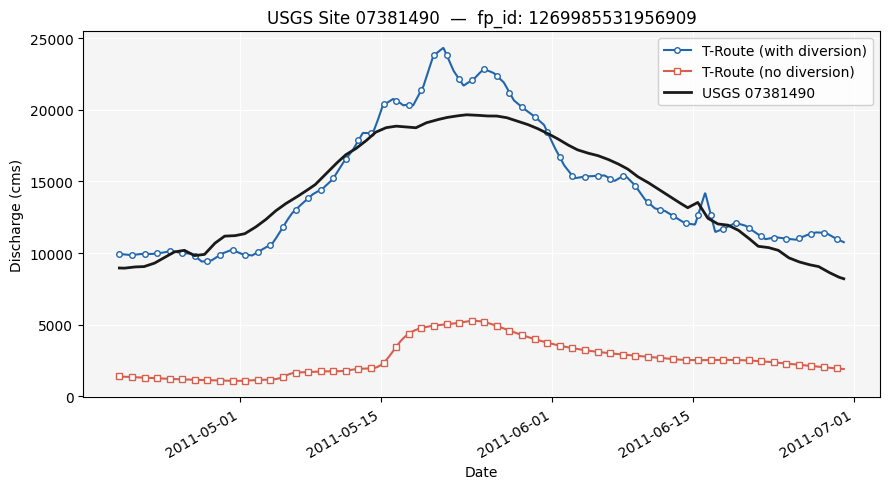

In [4]:

compare_runs(
    output_a="output",
    output_b="output_no_diversion",
    sites=SITES,
    label_a="T-Route (with diversion)",
    label_b="T-Route (no diversion)",
    suffix="_diversion",
)


In [5]:
# The diversion gage's record is cut at 2011-05-31 in usgs_da_persist while the
# forcing and the other gages run on; the last observation is held.
nhf_routing(["-f", "config_persist.yaml"])

2026-09-15 16:37:08,839 - TROUTE - INFO - [NHF.py:87 - __init__]: creating NHF supernetwork connections set


2026-09-15 16:37:08,910 - TROUTE - INFO - [nhf_preprocess.py:732 - _clean_waterbodies]: waterbodies: 3 of 3 lakes retained for reservoir routing


2026-09-15 16:37:08,953 - TROUTE - WARNING - [nhf_preprocess.py:1496 - _one_link_per_gage]: gages: 1 USGS gage(s) share a routing link with another gage; keeping the active gage nearest the downstream nexus and dropping the rest, e.g. ['07293500']


2026-09-15 16:37:08,955 - TROUTE - INFO - [nhf_preprocess.py:1506 - _one_link_per_gage]: gages: 8 USGS gage(s) placed on 8 routing link(s)


2026-09-15 16:37:08,971 - TROUTE - DEBUG - [nhf_preprocess.py:1648 - _resolve_diversion_da]: Diversion configured: fp_id 1270479816524705 (node 1271023511891281) -> gage 07381482 (node 1271023511890341)


...

2026-09-15 16:38:00,480 - TROUTE - INFO - [nhf_routing.py:459 - nhf_routing]: Forcing array construction: 34.43 secs, 66.66 %


2026-09-15 16:38:00,480 - TROUTE - INFO - [nhf_routing.py:466 - nhf_routing]: Routing computations: 16.39 secs, 31.74 %


2026-09-15 16:38:00,480 - TROUTE - INFO - [nhf_routing.py:473 - nhf_routing]: Output writing: 0.68 secs, 1.32 %


2026-09-15 16:38:00,480 - TROUTE - INFO - [nhf_routing.py:480 - nhf_routing]: ----------------------------------------


2026-09-15 16:38:00,480 - TROUTE - INFO - [nhf_routing.py:481 - nhf_routing]: Total execution time: 51.64 secs


/var/folders/jx/s06wj7hs325c_2yd2g5209sr0000gp/T/ipykernel_95104/573723478.py:19: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.concat([xr.open_dataset(p, engine="netcdf4") for p in files], dim="time")
/var/folders/jx/s06wj7hs325c_2yd2g5209sr0000gp/T/ipykernel_95104/573723478.py:19: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or 

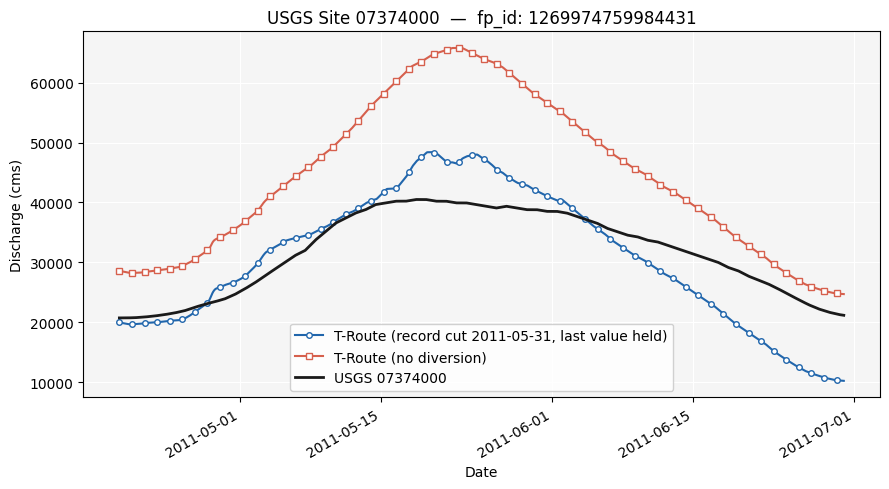

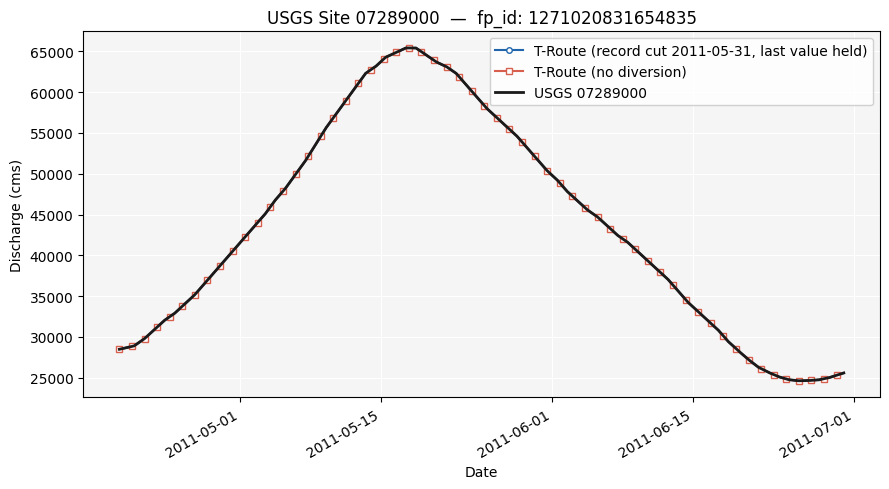

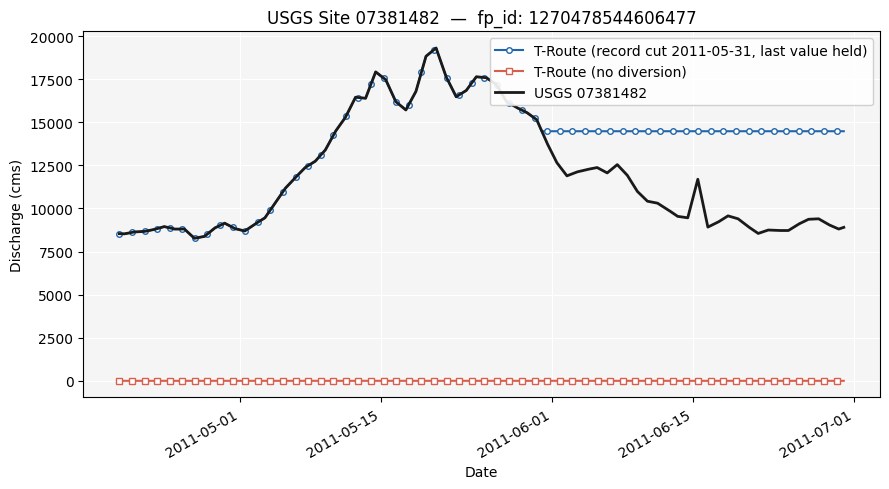

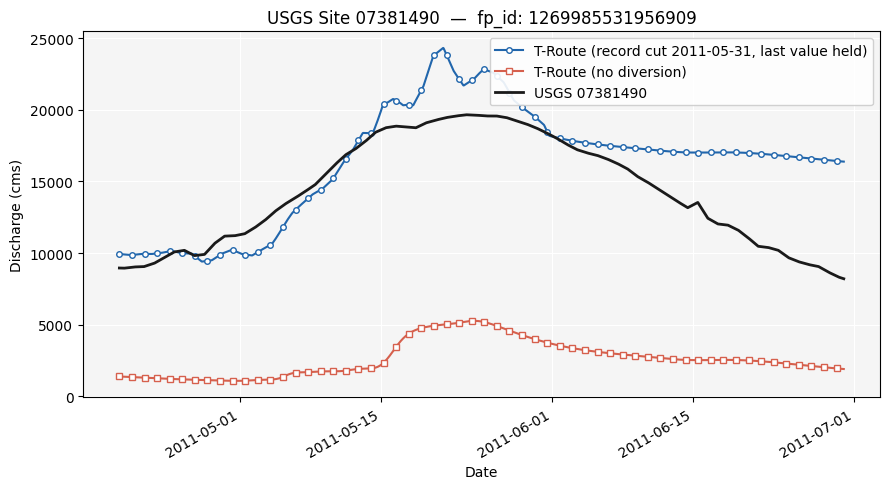

In [6]:
compare_runs(
    output_a="output_persist",
    output_b="output_no_diversion",
    sites=SITES,
    label_a="T-Route (record cut 2011-05-31, last value held)",
    label_b="T-Route (no diversion)",
    suffix="_persist",
)


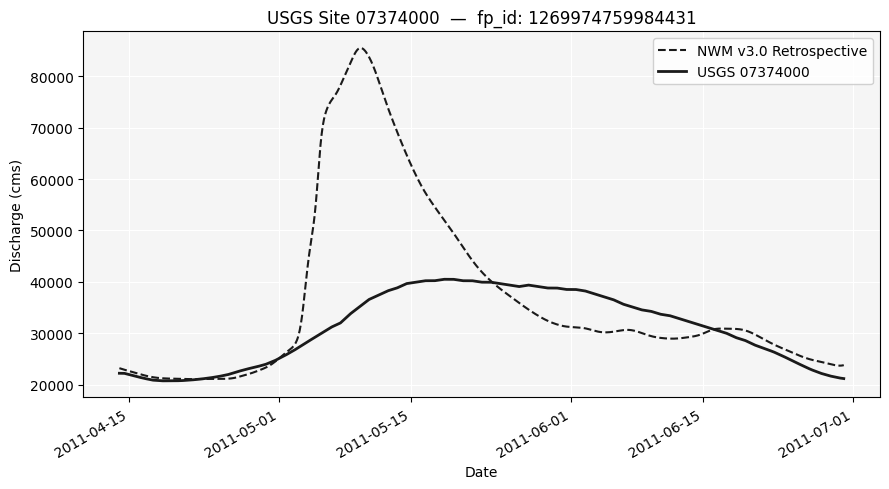

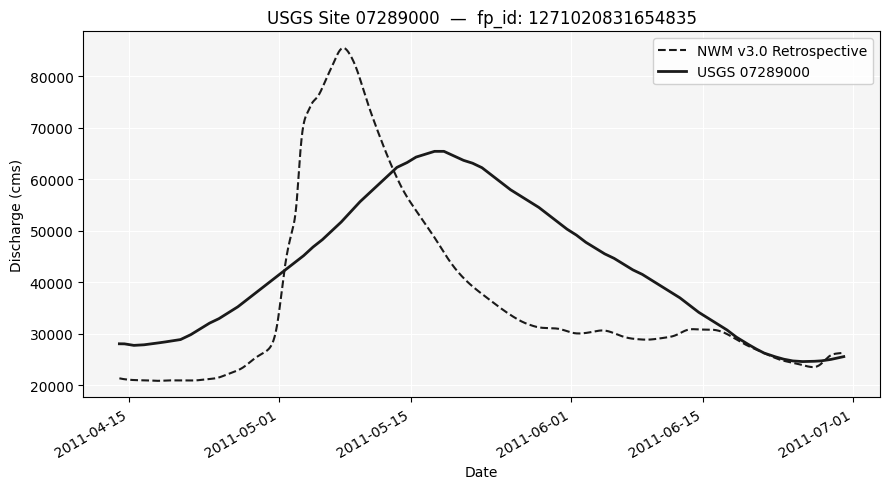

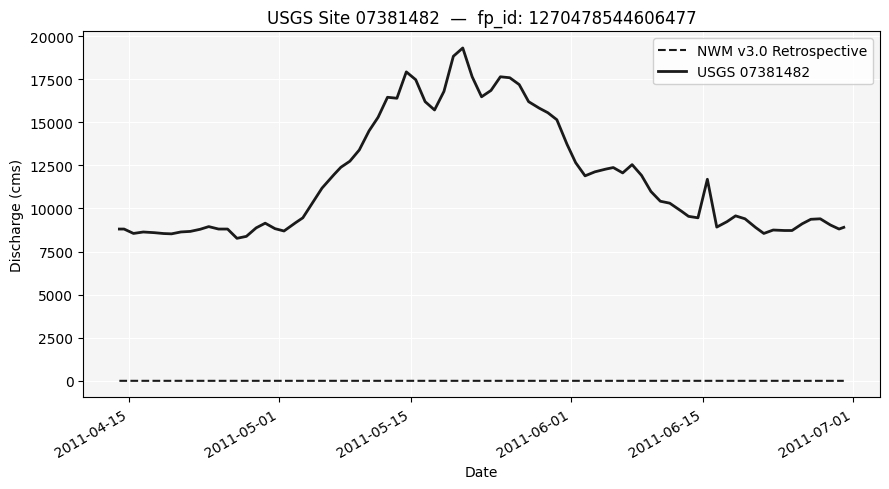

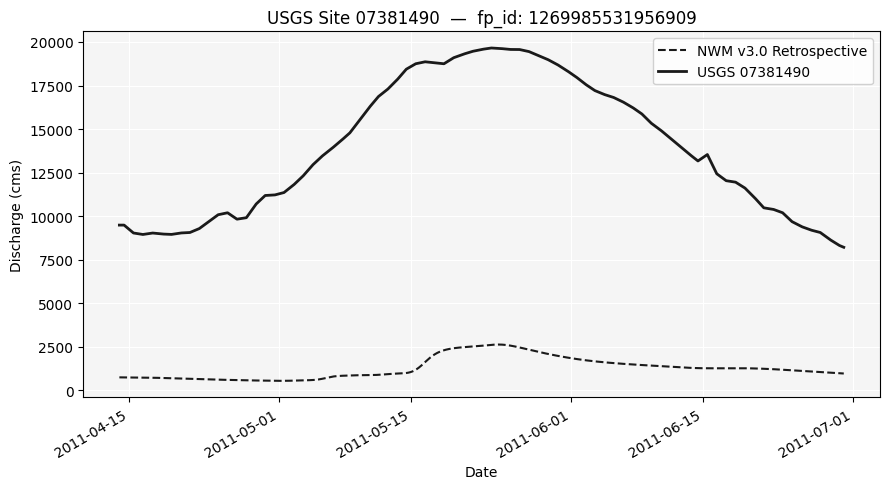

In [7]:
compare_retro(sites=SITES)
